In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, LayerNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.utils import to_categorical
import pandas as pd

In [3]:
def plot_history(history, title):
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Accuracy Plot (Top)
    axs[0].plot(history.history['accuracy'], label="Train Accuracy")
    axs[0].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axs[0].set_title(f"Model Accuracy - {title}")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")

    # Loss Plot (Bottom)
    axs[1].plot(history.history['loss'], label="Train Loss")
    axs[1].plot(history.history['val_loss'], label="Validation Loss")
    axs[1].set_title(f"Model Loss - {title}")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Loss")
    axs[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [4]:
# Load Data
df = pd.read_csv("../stroke/stroke_features.csv")

In [5]:
df.head()

,HipAngles,KneeAngles,AnkleAngles,Subject,Label,HipAngles_Variability,KneeAngles_Variability,AnkleAngles_Variability,HipAngles_Acceleration,KneeAngles_Acceleration,AnkleAngles_Acceleration
0,30.049283,11.570827,-2.482850,Sub01,0,16.378885,16.962906,8.289713,0.000000,0.000000,0.000000
1,30.037282,11.714903,-2.519216,Sub01,0,16.378885,16.962906,8.289713,-0.012002,0.144076,-0.036365
2,30.024681,11.858510,-2.555104,Sub01,0,16.378885,16.962906,8.289713,-0.012600,0.143607,-0.035889
3,30.011461,12.001644,-2.590505,Sub01,0,16.378885,16.962906,8.289713,-0.013220,0.143134,-0.035401
4,29.997598,12.144301,-2.625407,Sub01,0,16.378885,16.962906,8.289713,-0.013863,0.142657,-0.034902


In [6]:
# Separate Features & Labels
X = df.drop(columns=["Label","Subject"])
y = df["Label"]

In [7]:
X.head()

,HipAngles,KneeAngles,AnkleAngles,HipAngles_Variability,KneeAngles_Variability,AnkleAngles_Variability,HipAngles_Acceleration,KneeAngles_Acceleration,AnkleAngles_Acceleration
0,30.049283,11.570827,-2.482850,16.378885,16.962906,8.289713,0.000000,0.000000,0.000000
1,30.037282,11.714903,-2.519216,16.378885,16.962906,8.289713,-0.012002,0.144076,-0.036365
2,30.024681,11.858510,-2.555104,16.378885,16.962906,8.289713,-0.012600,0.143607,-0.035889
3,30.011461,12.001644,-2.590505,16.378885,16.962906,8.289713,-0.013220,0.143134,-0.035401
4,29.997598,12.144301,-2.625407,16.378885,16.962906,8.289713,-0.013863,0.142657,-0.034902


In [17]:
from sklearn.kernel_approximation import RBFSampler

# Step 1: Full RFF transformation using best params
rff = RBFSampler(gamma=0.1, n_components=16, random_state=42)  # You can tune n_components
X_rff_all = rff.fit_transform(X)

n_pca = 4

# Step 2: Train/val split (after RFF)
X_train_full, X_val_full, y_train, y_val = train_test_split(X_rff_all, y, test_size=0.2, random_state=42)

# Step 3: Apply PCA (cap to max dim if needed)
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_full)
X_val_pca = pca.transform(X_val_full)

# Step 4: Reshape for RNN
X_train_rnn = X_train_pca.reshape(-1, 1, n_pca)
X_val_rnn = X_val_pca.reshape(-1, 1, n_pca)

# Step 5: Define final model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(1, X_train_rnn.shape[2])),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, clipvalue=0.5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Train
history = model.fit(X_train_rnn, y_train, epochs=30, validation_data=(X_val_rnn, y_val), batch_size=32, verbose=1)

Epoch 1/30


c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2503/2503 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.5358 - loss: 0.6898 - val_accuracy: 0.5442 - val_loss: 0.6875
Epoch 2/30
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5441 - loss: 0.6864 - val_accuracy: 0.5527 - val_loss: 0.6854
Epoch 3/30
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5543 - loss: 0.6844 - val_accuracy: 0.5573 - val_loss: 0.6839
Epoch 4/30
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5569 - loss: 0.6831 - val_accuracy: 0.5608 - val_loss: 0.6823
Epoch 5/30
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5598 - loss: 0.6817 - val_accuracy: 0.5612 - val_loss: 0.6814
Epoch 6/30
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5606 - loss: 0.6805 - val_accuracy: 0.5634 - val_loss: 0.6797
Epoch 7/30
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5629 - loss: 0.6797 - val_accuracy: 0.5658 - val_loss: 0.6790
Epoch 8/30
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5640 - loss: 0.6789 - val_accurac

In [18]:
# ✅ Evaluate
test_loss, test_acc = model.evaluate(X_val_rnn, y_val)
print(f"DNN Test Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5797 - loss: 0.6722
DNN Test Accuracy: 0.5797 | Loss: 0.6722


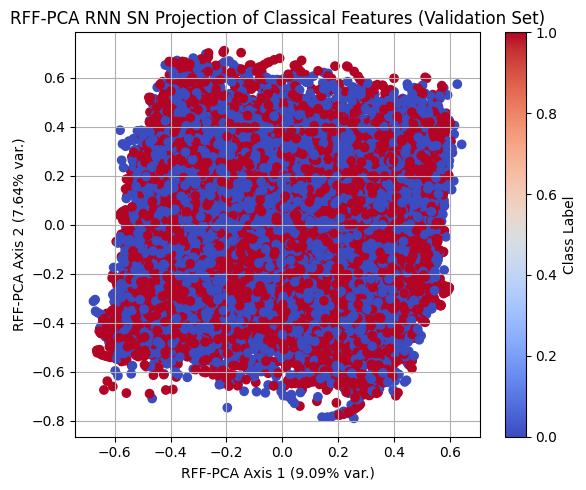

In [15]:
import matplotlib.pyplot as plt

# Project the validation data to 2D using a new PCA for visualization
pca_vis = PCA(n_components=2)
X_val_vis = pca_vis.fit_transform(X_val_full)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X_val_vis[:, 0], X_val_vis[:, 1], c=y_val, cmap="coolwarm")
plt.xlabel(f"RFF-PCA Axis 1 ({pca_vis.explained_variance_ratio_[0]*100:.2f}% var.)")
plt.ylabel(f"RFF-PCA Axis 2 ({pca_vis.explained_variance_ratio_[1]*100:.2f}% var.)")
plt.title("RFF-PCA RNN SN Projection of Classical Features (Validation Set)")
plt.colorbar(label="Class Label")
plt.grid(True)
plt.tight_layout()
plt.show()


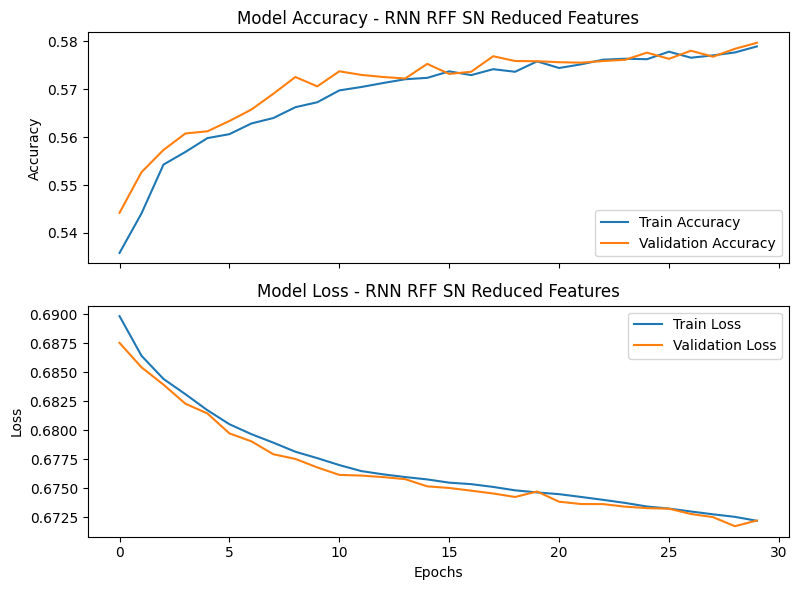

In [19]:
plot_history(history, "RNN RFF SN Reduced Features")

626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


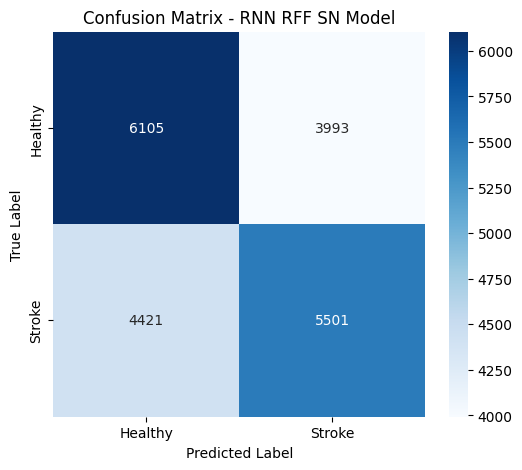

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.60      0.59     10098
           1       0.58      0.55      0.57      9922

    accuracy                           0.58     20020
   macro avg       0.58      0.58      0.58     20020
weighted avg       0.58      0.58      0.58     20020



In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Get Model Predictions
y_pred_probs = model.predict(X_val_rnn)  # Get prediction probabilities


# Step 2: Adjust Decision Threshold
threshold = 0.5
y_pred = (y_pred_probs[:, 0] > threshold).astype(int)

# Step 3: Convert one-hot encoded labels (if needed)
if len(y_val.shape) > 1 and y_val.shape[1] > 1:  # Check safely
    y_test = np.argmax(y_val, axis=1)  # Converts one-hot labels back to single-class


# Step 4: Compute Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# Step 5: Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Healthy", "Stroke"], yticklabels=["Healthy", "Stroke"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - RNN RFF SN Model")
plt.show()

# 🔹 Step 6: Print Classification Report
print("Classification Report:\n", classification_report(y_val, y_pred))

# K-Fold

In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Define number of folds
k = 5  
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Store metrics
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

# Placeholder for epoch-wise averaging
all_train_acc = []
all_val_acc = []
all_train_loss = []
all_val_loss = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):
    print(f"\nTraining Fold {fold+1}/{k}")

    y_train = y_train.reset_index(drop=True)

    # Split data
    X_train_fold, X_val_fold = X_train_full[train_idx], X_train_full[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Sequential model (LSTM)
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train_full.shape[1], 1)),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    # Compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                loss="binary_crossentropy",
                metrics=["accuracy"])

    # Train model
    history = model.fit(X_train_fold, y_train_fold, 
                        epochs=20, batch_size=32, 
                        validation_data=(X_val_fold, y_val_fold), 
                        verbose=1)

    # Store per-epoch results
    train_accuracies.append(history.history['accuracy'])
    val_accuracies.append(history.history['val_accuracy'])
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

    # Evaluate model
    _, accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")


Training Fold 1/5


c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.5161 - loss: 0.6921 - val_accuracy: 0.5244 - val_loss: 0.6911
Epoch 2/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5345 - loss: 0.6896 - val_accuracy: 0.5275 - val_loss: 0.6896
Epoch 3/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5369 - loss: 0.6884 - val_accuracy: 0.5255 - val_loss: 0.6895
Epoch 4/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5366 - loss: 0.6875 - val_accuracy: 0.5292 - val_loss: 0.6888
Epoch 5/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5376 - loss: 0.6872 - val_accuracy: 0.5361 - val_loss: 0.6882
Epoch 6/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5407 - loss: 0.6867 - val_accuracy: 0.5338 - val_loss: 0.6882
Epoch 7/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5430 - loss: 0.6862 - val_accuracy: 0.5392 - val_loss: 0.6882
Epoch 8/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5442 - loss: 

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5172 - loss: 0.6923 - val_accuracy: 0.5307 - val_loss: 0.6912
Epoch 2/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5320 - loss: 0.6894 - val_accuracy: 0.5375 - val_loss: 0.6875
Epoch 3/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5412 - loss: 0.6869 - val_accuracy: 0.5460 - val_loss: 0.6863
Epoch 4/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5431 - loss: 0.6862 - val_accuracy: 0.5490 - val_loss: 0.6855
Epoch 5/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5465 - loss: 0.6858 - val_accuracy: 0.5474 - val_loss: 0.6859
Epoch 6/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5473 - loss: 0.6854 - val_accuracy: 0.5488 - val_loss: 0.6847
Epoch 7/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5488 - loss: 0.6849 - val_accuracy: 0.5495 - val_loss: 0.6854
Epoch 8/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5486 - loss: 0

...

2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5177 - loss: 0.6923 - val_accuracy: 0.5333 - val_loss: 0.6899
Epoch 2/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5332 - loss: 0.6892 - val_accuracy: 0.5389 - val_loss: 0.6871
Epoch 3/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5406 - loss: 0.6873 - val_accuracy: 0.5460 - val_loss: 0.6865
Epoch 4/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5423 - loss: 0.6866 - val_accuracy: 0.5481 - val_loss: 0.6866
Epoch 5/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5429 - loss: 0.6861 - val_accuracy: 0.5496 - val_loss: 0.6862
Epoch 6/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5447 - loss: 0.6859 - val_accuracy: 0.5483 - val_loss: 0.6861
Epoch 7/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5463 - loss: 0.6856 - val_accuracy: 0.5544 - val_loss: 0.6858
Epoch 8/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5477 - loss: 0.6855 - val

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5215 - loss: 0.6915 - val_accuracy: 0.5389 - val_loss: 0.6891
Epoch 2/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5347 - loss: 0.6891 - val_accuracy: 0.5374 - val_loss: 0.6877
Epoch 3/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5344 - loss: 0.6882 - val_accuracy: 0.5367 - val_loss: 0.6871
Epoch 4/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5373 - loss: 0.6876 - val_accuracy: 0.5356 - val_loss: 0.6874
Epoch 5/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5416 - loss: 0.6871 - val_accuracy: 0.5437 - val_loss: 0.6861
Epoch 6/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5443 - loss: 0.6865 - val_accuracy: 0.5441 - val_loss: 0.6866
Epoch 7/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5457 - loss: 0.6861 - val_accuracy: 0.5471 - val_loss: 0.6854
Epoch 8/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5476 - loss: 0.6858 - val

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2002/2002 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.5236 - loss: 0.6913 - val_accuracy: 0.5283 - val_loss: 0.6900
Epoch 2/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5335 - loss: 0.6886 - val_accuracy: 0.5308 - val_loss: 0.6888
Epoch 3/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5352 - loss: 0.6878 - val_accuracy: 0.5361 - val_loss: 0.6876
Epoch 4/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5384 - loss: 0.6873 - val_accuracy: 0.5367 - val_loss: 0.6870
Epoch 5/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5413 - loss: 0.6867 - val_accuracy: 0.5386 - val_loss: 0.6865
Epoch 6/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5426 - loss: 0.6864 - val_accuracy: 0.5463 - val_loss: 0.6854
Epoch 7/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5454 - loss: 0.6860 - val_accuracy: 0.5431 - val_loss: 0.6858
Epoch 8/20
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5493 - loss: 0.6856 - val


Final K-Fold Accuracy: 0.5575


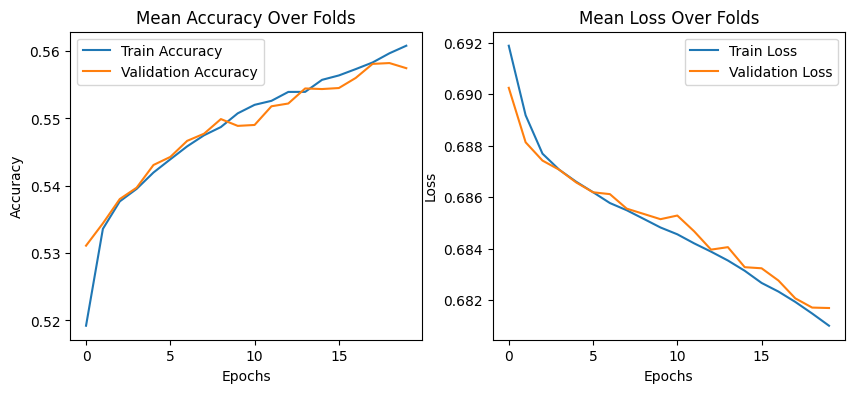

In [10]:
# Convert lists to NumPy arrays for easy averaging
train_accuracies = np.array(train_accuracies)
val_accuracies = np.array(val_accuracies)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)

# Compute mean accuracy/loss across folds
mean_train_acc = np.mean(train_accuracies, axis=0)
mean_val_acc = np.mean(val_accuracies, axis=0)
mean_train_loss = np.mean(train_losses, axis=0)
mean_val_loss = np.mean(val_losses, axis=0)

# 🎯 Final mean accuracy across folds
final_accuracy = np.mean(val_accuracies[:, -1])
print(f"\nFinal K-Fold Accuracy: {final_accuracy:.4f}")

# 📊 Plot Accuracy Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(mean_train_acc, label='Train Accuracy')
plt.plot(mean_val_acc, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Mean Accuracy Over Folds")
plt.legend()

# 📊 Plot Loss Curves
plt.subplot(1, 2, 2)
plt.plot(mean_train_loss, label='Train Loss')
plt.plot(mean_val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Mean Loss Over Folds")
plt.legend()

plt.show()

In [11]:
import pandas as pd
import numpy as np

# Convert lists to numpy arrays
folds = list(range(1, len(train_accuracies) + 1))

# Create DataFrame with results per fold
df_results = pd.DataFrame({
    'Fold': folds,
    'Final Train Accuracy': [train_acc[-1] for train_acc in train_accuracies],
    'Final Validation Accuracy': [val_acc[-1] for val_acc in val_accuracies],
    'Final Train Loss': [train_loss[-1] for train_loss in train_losses],
    'Final Validation Loss': [val_loss[-1] for val_loss in val_losses]
})

# Print results
print("\n📊 K-Fold Cross-Validation Results:\n")
print(df_results)

# Compute summary statistics (mean & std deviation)
df_summary = df_results.describe().loc[['mean', 'std']]
print("\n📌 Summary Statistics (Mean & Std Deviation):\n")
print(df_summary)


📊 K-Fold Cross-Validation Results:

   Fold  Final Train Accuracy  Final Validation Accuracy  Final Train Loss  \
0     1              0.554836                   0.549138          0.683076   
1     2              0.575784                   0.572053          0.675632   
2     3              0.552853                   0.556006          0.682385   
3     4              0.560830                   0.551386          0.681358   
4     5              0.559644                   0.558691          0.682572   

   Final Validation Loss  
0               0.684482  
1               0.676168  
2               0.682745  
3               0.682617  
4               0.682451  

📌 Summary Statistics (Mean & Std Deviation):

          Fold  Final Train Accuracy  Final Validation Accuracy  \
mean  3.000000              0.560789                   0.557455   
std   1.581139              0.009008                   0.008982   

      Final Train Loss  Final Validation Loss  
mean          0.681005             